In [ ]:
!pip install shap lime -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 7.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


In [ ]:
# Importação de todas as bibliotecas que serão utilizadas
import pandas as pd
import numpy as np
import seaborn as sns
import shap
import lime
from lime import lime_tabular
import json
from openai import OpenAI
import matplotlib.pyplot as plt
from sklearn.preprocessing import OneHotEncoder, LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
import xgboost as xgb
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split

In [ ]:
# Define o dataset que será utilizado, disponível em: https://www.kaggle.com/datasets/developerghost/intrusion-detection-logs-normal-bot-scan/code
df = pd.read_csv("./Network_logs.csv")

In [ ]:
# Cria uma cópia do dataset original para garantir que nenhum dado original foi alterado acidentalmente
networkData = df.copy()
networkData.head(5)

,Source_IP,Destination_IP,Port,Request_Type,Protocol,Payload_Size,User_Agent,Status,Intrusion,Scan_Type
0,192.168.142.55,42.156.67.167,80,FTP,UDP,2369,curl/7.68.0,Success,0,Normal
1,53.39.165.18,94.60.242.119,135,SMTP,UDP,1536,Wget/1.20.3,Failure,1,BotAttack
2,192.168.127.91,7.10.192.3,21,SMTP,TCP,1183,Wget/1.20.3,Success,0,Normal
3,192.168.30.40,130.169.82.211,25,HTTPS,TCP,666,Mozilla/5.0,Success,0,Normal
4,192.168.43.179,35.140.102.220,22,FTP,TCP,2821,Mozilla/5.0,Success,0,Normal


In [ ]:
# Descarta as features/colunas IP de Origem e IP de destino devido a alta cardinalidade e irrelevãncia e a feature Intrusion para evitar overfitting
networkData.drop(['Source_IP', 'Destination_IP', 'Intrusion'], axis=1, inplace=True)
networkData.head(5)

,Port,Request_Type,Protocol,Payload_Size,User_Agent,Status,Scan_Type
0,80,FTP,UDP,2369,curl/7.68.0,Success,Normal
1,135,SMTP,UDP,1536,Wget/1.20.3,Failure,BotAttack
2,21,SMTP,TCP,1183,Wget/1.20.3,Success,Normal
3,25,HTTPS,TCP,666,Mozilla/5.0,Success,Normal
4,22,FTP,TCP,2821,Mozilla/5.0,Success,Normal


In [ ]:
# Codificação para as features/colunas com valores não numéricos
categorical_cols = ['Request_Type', 'Protocol', 'User_Agent', 'Status', 'Port']
for col in categorical_cols:
    networkData[col] = networkData[col].astype('category')

In [ ]:
for col in categorical_cols:
    print(f"{col} categories: {networkData[col].cat.categories.tolist()}")

Request_Type categories: ['DNS', 'FTP', 'HTTP', 'HTTPS', 'SMTP', 'SSH', 'Telnet']
Protocol categories: ['ICMP', 'TCP', 'UDP']
User_Agent categories: ['Mozilla/5.0', 'Nikto/2.1.6', 'Wget/1.20.3', 'curl/7.68.0', 'nmap/7.80', 'python-requests/2.25.1']
Status categories: ['Failure', 'Success']
Port categories: [21, 22, 23, 25, 53, 80, 135, 443, 4444, 6667, 8080, 31337]


In [ ]:
for col in categorical_cols:
    networkData[col] = networkData[col].cat.codes

In [ ]:
# Codificação da variável Alvo/Classificação (y) para valor numérico: BotAttack ->0; Normal ->1; ScanPort ->2;
target_encoder = LabelEncoder()
networkData['Scan_Type_Label'] = target_encoder.fit_transform(networkData['Scan_Type'])

In [ ]:
label_mapping = dict(zip(target_encoder.classes_, target_encoder.transform(target_encoder.classes_)))
print("Label Mapping:", label_mapping)

Label Mapping: {'BotAttack': np.int64(0), 'Normal': np.int64(1), 'PortScan': np.int64(2)}


In [ ]:
networkData.drop(['Scan_Type'], axis=1, inplace=True)
networkData.head(5)

,Port,Request_Type,Protocol,Payload_Size,User_Agent,Status,Scan_Type_Label
0,5,1,2,2369,3,1,1
1,6,4,2,1536,2,0,0
2,0,4,1,1183,2,1,1
3,3,3,1,666,0,1,1
4,1,1,1,2821,0,1,1


In [ ]:
# Normalização/Transformação do valor númerico da feature/colunas Payload_size
scaler = StandardScaler()
networkData['Payload_Size'] = scaler.fit_transform(networkData[['Payload_Size']])

In [ ]:
networkData.head(5)

,Port,Request_Type,Protocol,Payload_Size,User_Agent,Status,Scan_Type_Label
0,5,1,2,0.841271,3,1,1
1,6,4,2,-0.068551,2,0,0
2,0,4,1,-0.454106,2,1,1
3,3,3,1,-1.018786,0,1,1
4,1,1,1,1.334957,0,1,1


In [ ]:
# Define o que são as features para treinamento (X) e o que é o alvo/classificação (y)
X = networkData.drop(['Scan_Type_Label'], axis=1)
y = networkData['Scan_Type_Label']

In [ ]:
# Informa a chave da API da OpenAI
client = OpenAI(api_key="coloca a chave da API aqui")

In [ ]:
# Amostra para não enviar dataset inteiro para o LLM
#sample_df = networkData.sample(n=min(50, len(networkData)), random_state=42)
#sample_df

In [ ]:
# Particiona o dataset (networkData) em 70% para treinamento e 30% para teste, use o parâmetro "stratify" para assegurar uma proporção igual da classe "y" ("Scan_Type_Label") em cada conjunto (Treinamento e Teste)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y)

In [ ]:
# Instancia o objeto de sobreamostragem SMOTE com as configurações padrão. Necessário para dataset desequilibrados
smote = SMOTE()

# Aplica a técnica de sobreamostragem SMOTE aos dados de treinamento do modelo (NÃO aplicar aos dados de teste, para evitar memorização) para equilibrar a classe minoritária da variável alvo (para equilibrar a quantidade de 0s e 1s).
X_train, y_train = smote.fit_resample(X_train, y_train)

# Restaura y_train para uma série do pandas
y_train = pd.Series(y_train.values.ravel(), name='Scan_Type_Label')

# Mensagem de sucesso confirmando a nova distribuição da classe alvo/classificação
print('Técnica SMOTE aplicada com sucesso aos dados de treinamento.' + '\n' + '\n' + 'Nova distribuição de y alvo/classificação:' + '\n' + '\n' + str(y_train.value_counts()) + '\n' + '\n')


Técnica SMOTE aplicada com sucesso aos dados de treinamento.

Nova distribuição de y alvo/classificação:

Scan_Type_Label
1    5600
0    5600
2    5600
Name: count, dtype: int64




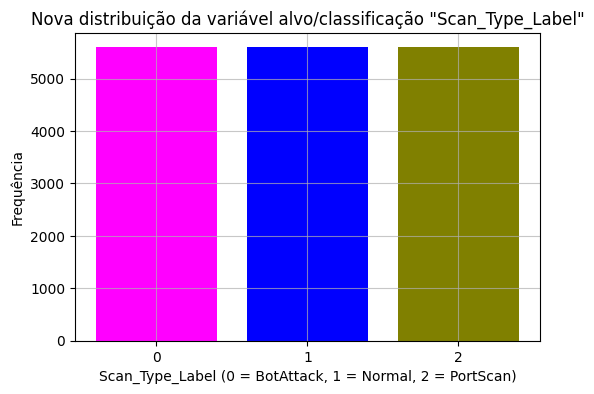

In [ ]:
# Contagem de 0's, 1's e 2's da variável alvo/classificação.
ScanTypeCounts = y_train.value_counts().sort_index()

# Cria uma figura com a nova distribuição equilibrada da variável alvo/classificação.
fig, ax = plt.subplots(figsize=(6, 4))

# Cores para cada classe
cores = ['#FF00FF', 'blue', '#808000']

# Plotagem
ax.bar(ScanTypeCounts.index.astype(str), ScanTypeCounts.values, color=cores)

ax.grid(True, alpha=0.7)
ax.set_title('Nova distribuição da variável alvo/classificação "Scan_Type_Label"')
ax.set_xlabel('Scan_Type_Label (0 = BotAttack, 1 = Normal, 2 = PortScan)')
ax.set_ylabel('Frequência')

plt.show()

In [ ]:
# Define a lista de algoritmos de classificação que serão utilizados para treinar o modelo
models = {
    #'Logistic Regression': LogisticRegression(max_iter=1000),
    #'KNN': KNeighborsClassifier(),
    #'Decision Tree': DecisionTreeClassifier(),
    'Random Forest': RandomForestClassifier(),
    #'XGBoost': xgb.XGBClassifier(use_label_encoder=False, eval_metric='mlogloss'),
    #'MLP': MLPClassifier(max_iter=500)
}

In [ ]:
# Seleciona uma amostra aleatória do conjunto de teste (X_test), limitada a no máximo 200 linhas para ser utilizado no SHAP
sample_idx = np.random.choice(X_test.index, size=min(200, len(X_test)), replace=False)
X_sample = X_test.loc[sample_idx]


🔍 Treinamento do modelo utilizando o algorítmo Random Forest...
✅ Acurácia: 0.9974
              precision    recall  f1-score   support

           0       0.97      0.99      0.98       144
           1       1.00      1.00      1.00      2400
           2       0.99      1.00      1.00       110

    accuracy                           1.00      2654
   macro avg       0.99      0.99      0.99      2654
weighted avg       1.00      1.00      1.00      2654

📊 Explicação SHAP para Random Forest


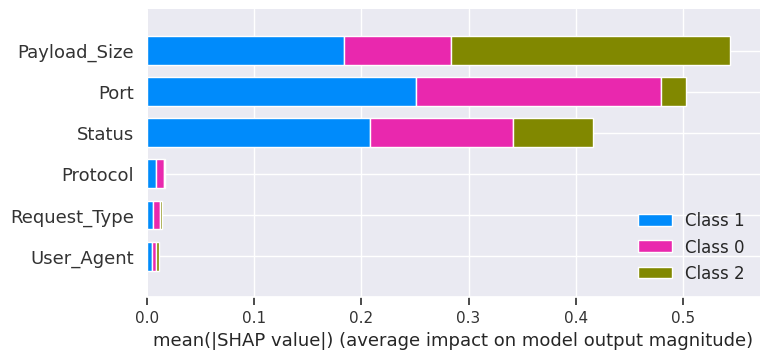

In [ ]:
for name, model in models.items():
    print(f"\n🔍 Treinamento do modelo utilizando o algorítmo {name}...")
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    print(f"✅ Acurácia: {acc:.4f}")
    print(classification_report(y_test, y_pred))

    print(f"📊 Explicação SHAP para {name}")

    if name in ['Random Forest', 'XGBoost', 'Decision Tree']:
        explainer = shap.TreeExplainer(model)
        shap_values = explainer.shap_values(X_sample)

        shap.summary_plot(
            shap_values,
            X_sample,
            plot_type="bar",
            show=True
        )

    else:
        explainer = shap.KernelExplainer(model.predict_proba, X_train.iloc[:100])
        shap_values = explainer.shap_values(X_sample)

        shap.summary_plot(
            shap_values,
            X_sample,
            plot_type="bar",
            show=True
        )

In [ ]:
# View confusion matrix for test data and predictions
confusion_matrix(y_test, y_pred)

array([[ 142,    2,    0],
       [   4, 2395,    1],
       [   0,    0,  110]])

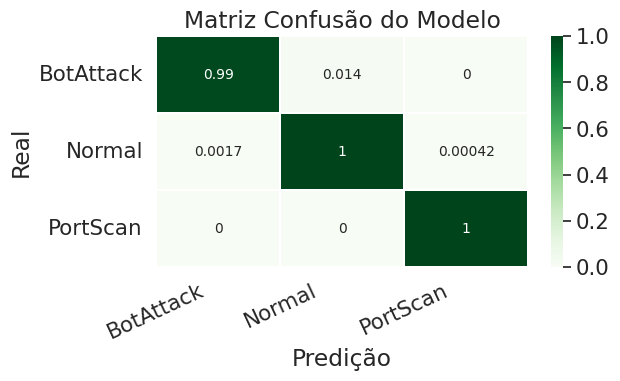

In [ ]:
# Get and reshape confusion matrix data
matrix = confusion_matrix(y_test, y_pred)
matrix = matrix.astype('float') / matrix.sum(axis=1)[:, np.newaxis]

# Build the plot
plt.figure(figsize=(6,3))
sns.set(font_scale=1.4)
sns.heatmap(matrix, annot=True, annot_kws={'size':10},
            cmap=plt.cm.Greens, linewidths=0.2)

# Add labels to the plot
class_names = ['BotAttack', 'Normal', 'PortScan']
tick_marks = np.arange(len(class_names))
tick_marks2 = tick_marks + 0.5
plt.xticks(tick_marks, class_names, rotation=25)
plt.yticks(tick_marks2, class_names, rotation=0)
plt.xlabel('Predição')
plt.ylabel('Real')
plt.title('Matriz Confusão do Modelo')
plt.show()

In [ ]:
# ==========================
# DESCRIÇÃO DAS COLUNAS
# ==========================
column_description = {
    "Port": "Porta utilizada na comunicação",
    "Request_Type": "Tipo de requisição",
    "Protocol": "Protoloco da Camada de Transporte, segundo o modelo OSI, podendo ser: TCP ou UDP",
    "Payload_Size": "Tamanho do pacote (informação útil)",
    "User_Agent": "Agente utilizado na comunicação",
    "Status": "Status da requisção, podendo ser: Success ou Failure",
    "Scan_Type_Label": "Classificação da comunicação, podendo ser: normal ou botattack ou PortScan"
}

# ==========================
# EQUIVALÊNCIA CATEGORIA -> CÓDIGO NUMÉRICO DAS COLUNAS
# ==========================
category_encoding = {

    "Request_Type": {
        "DNS": 0,
        "FTP": 1,
        "HTTP": 2,
        "HTTPS": 3,
        "SMTP": 4,
        "SSH": 5,
        "Telnet": 6
    },

    "Protocol": {
        "ICMP": 0,
        "TCP": 1,
        "UDP": 2
    },

    "User_Agent": {
        "Mozilla/5.0": 0,
        "Nikto/2.1.6": 1,
        "Wget/1.20.3": 2,
        "curl/7.68.0": 3,
        "nmap/7.80": 4,
        "python-requests/2.25.1": 5
    },

    "Status": {
        "Failure": 0,
        "Success": 1
    },

    "Port": {
        21: 0,
        22: 1,
        23: 2,
        25: 3,
        53: 4,
        80: 5,
        135: 6,
        443: 7,
        4444: 8,
        6667: 9,
        8080: 10,
        31337: 11
    },

    "Scan_Type_Label": {
        "BotAttack": 0,
        "Normal": 1,
        "PortScan": 2
    }
}

# Estatísticas do Dataset
stats = networkData.describe(include="all").to_string()

# juntar X e y
#train_df = X_train.copy()
#train_df["Scan_Type_Label"] = y_train

#samples_per_class = 17 # 51 amostras no total (3 classes = 51)

#train_sample = (
#    train_df
#    .groupby("Scan_Type_Label", group_keys=False)
#    .apply(lambda x: x.sample(min(len(x), samples_per_class)))
#)
# train_sample_json = train_sample.to_json(orient="records")

# Amostra dos dados de treinamento
train_sample = X_train.sample(50)
train_sample["Scan_Type_Label"] = y_train.loc[train_sample.index]
train_sample_json = train_sample.to_json(orient="records")

# Amostra das previsões vs real
#samples_per_class = 17  # 51 amostras no total (3 classes = 51)

#balanced_sample = (
#    pred_sample
#    .groupby("real", group_keys=False)
#    .apply(lambda x: x.sample(min(len(x), samples_per_class)))
#)

#pred_sample_json = balanced_sample.to_json(orient="records")

# Amostra das previsões vs real
pred_sample = pd.DataFrame({
    "real": y_test,
    "predicted": y_pred
})

pred_sample_json = pred_sample.sample(50).to_json(orient="records")

# ==========================
# INFORMAÇÕES DO MODELO
# ==========================
model_info = {
    "model_type": "Logistic Regression",
    "task": "Detecção de intrusão a partir de log. Cada entrada do log é classificada como: BotAttack (0) ou Normal(1) ou PortScan (2)",
    "target_variable": "Scan_Type_Label",
    "features": list(X.columns)
}

In [ ]:
train_sample_json

'[{"Port":2,"Request_Type":5,"Protocol":1,"Payload_Size":0.3150208008,"User_Agent":1,"Status":0,"Scan_Type_Label":0},{"Port":1,"Request_Type":2,"Protocol":2,"Payload_Size":-0.9477912242,"User_Agent":5,"Status":1,"Scan_Type_Label":1},{"Port":1,"Request_Type":3,"Protocol":1,"Payload_Size":0.5911521227,"User_Agent":1,"Status":1,"Scan_Type_Label":1},{"Port":5,"Request_Type":3,"Protocol":2,"Payload_Size":-0.8680588862,"User_Agent":3,"Status":1,"Scan_Type_Label":1},{"Port":8,"Request_Type":1,"Protocol":0,"Payload_Size":-1.7181723575,"User_Agent":1,"Status":0,"Scan_Type_Label":2},{"Port":11,"Request_Type":2,"Protocol":0,"Payload_Size":2.5451405171,"User_Agent":4,"Status":0,"Scan_Type_Label":0},{"Port":10,"Request_Type":5,"Protocol":0,"Payload_Size":-1.6310562247,"User_Agent":0,"Status":0,"Scan_Type_Label":2},{"Port":11,"Request_Type":1,"Protocol":0,"Payload_Size":3.4580983117,"User_Agent":2,"Status":0,"Scan_Type_Label":0},{"Port":5,"Request_Type":4,"Protocol":0,"Payload_Size":0.3923673894,"Us

In [ ]:
pred_sample_json

'[{"real":1,"predicted":0},{"real":1,"predicted":1},{"real":1,"predicted":0},{"real":1,"predicted":1},{"real":1,"predicted":1},{"real":1,"predicted":1},{"real":0,"predicted":0},{"real":1,"predicted":1},{"real":2,"predicted":2},{"real":1,"predicted":1},{"real":1,"predicted":1},{"real":1,"predicted":1},{"real":1,"predicted":1},{"real":1,"predicted":1},{"real":1,"predicted":1},{"real":1,"predicted":1},{"real":1,"predicted":1},{"real":1,"predicted":1},{"real":1,"predicted":1},{"real":1,"predicted":1},{"real":1,"predicted":0},{"real":1,"predicted":1},{"real":1,"predicted":1},{"real":0,"predicted":1},{"real":1,"predicted":1},{"real":1,"predicted":1},{"real":1,"predicted":0},{"real":1,"predicted":1},{"real":1,"predicted":1},{"real":1,"predicted":1},{"real":1,"predicted":1},{"real":1,"predicted":1},{"real":1,"predicted":1},{"real":1,"predicted":1},{"real":1,"predicted":1},{"real":1,"predicted":1},{"real":1,"predicted":0},{"real":1,"predicted":1},{"real":1,"predicted":1},{"real":1,"predicted":1

In [ ]:
# ==========================
# PROMPT PARA O LLM
# ==========================
prompt = f"""
Você é um especialista em Machine Learning e Explainable AI.
Sua tarefa é gerar uma explicabilidade interpretável do modelo treinado com o dataset fornecido.

Informações do modelo:
{json.dumps(model_info, indent=2)}

Descrição das colunas:
{json.dumps(column_description, indent=2)}

Estatísticas do dataset:
{stats}

Forneça uma análise detalhada contendo:

1. Identificação das features mais importantes
2. Possíveis relações entre variáveis e a variável alvo
3. Interpretação de padrões presentes nos dados
4. Possíveis vieses ou problemas no dataset
5. Como cada feature pode influenciar a predição do modelo
6. Sugestões de métodos formais de explicabilidade (SHAP, LIME, Feature Importance)
7. Explicação em linguagem acessível para usuários não técnicos

Estruture a resposta em seções claras e gere o código em python para criação dos gráficos que ilustram a sua explicação.
"""

In [ ]:
# ==========================
# PROMPT PARA O LLM
# ==========================
prompt = f"""
Você é especialista em Inteligência Artificial Explicável (XAI) e Segurança Cibernética.
Sua tarefa é analisar um modelo de aprendizado de máquina treinado e fornecer uma explicação detalhada de seu comportamento.

=========================
INFORMAÇÕES DO MODELO
=========================
{model_info}

=========================
DESCRIÇÃO DAS COLUNAS
=========================
{column_description}

=========================
CODIFICAÇÃO: CATEGORIA → VALOR NUMÉRICO
=========================
{category_encoding}

=========================
ESTATÍTISCA DO DATASET
=========================
{stats}

=========================
AMOSTRA DOS DADOS DE TREINAMENTO
=========================
{train_sample_json}

=========================
AMOSTRA DA CLASSIFICAÇÃO REAL vs CLASSIFICAÇÃO DO MODELO
=========================
{pred_sample_json}

=========================
TAREFA
=========================

Forneça uma análise detalhada da explicabilidade do modelo, incluindo:

1. Interpretação global e local do comportamento do modelo.
2. Quais características parecem ser mais influentes na previsão de classificação:
- Normal
- BotAttack
- PortScan
3. Identifique possíveis padrões ou correlações no conjunto de dados.
4. Analise a amostra de previsão e comente sobre possíveis classificações incorretas.
5. Explique como as codificações categóricas podem influenciar o comportamento do modelo.
6. Forneça insights de segurança cibernética com base nos padrões detectados nos logs.
7. Sugira possíveis melhorias para o modelo ou conjunto de dados.

Sua explicação deve ser técnica, porém clara, estruturada em seções e adequada para um relatório de aprendizado de máquina.
"""

In [ ]:
prompt

'\nVocê é especialista em Inteligência Artificial Explicável (XAI) e Segurança Cibernética.\nSua tarefa é analisar um modelo de aprendizado de máquina treinado e fornecer uma explicação detalhada de seu comportamento.\n\n=========================\nINFORMAÇÕES DO MODELO\n=========================\n{\'model_type\': \'Logistic Regression\', \'task\': \'Detecção de intrusão a partir de log. Cada entrada do log é classificada como: BotAttack (0) ou Normal(1) ou PortScan (2)\', \'target_variable\': \'Scan_Type_Label\', \'features\': [\'Port\', \'Request_Type\', \'Protocol\', \'Payload_Size\', \'User_Agent\', \'Status\']}\n\n=========================\nDESCRIÇÃO DAS COLUNAS\n=========================\n{\'Port\': \'Porta utilizada na comunicação\', \'Request_Type\': \'Tipo de requisição\', \'Protocol\': \'Protoloco da Camada de Transporte, segundo o modelo OSI, podendo ser: TCP ou UDP\', \'Payload_Size\': \'Tamanho do pacote (informação útil)\', \'User_Agent\': \'Agente utilizado na comunicação

In [ ]:
# ==========================
# CHAMADA DA API
# ==========================
response = client.responses.create(
    model="gpt-5",
    input=[
        {
            "role": "system",
            "content": "Você é um especialista em Machine Learning e Explainable AI."
        },
        {
            "role": "user",
            "content": prompt
        }
    ],
    max_output_tokens=10000
)

In [ ]:
# ==========================
# RESULTADO
# ==========================

explanation = ""

for item in response.output:
    if item.type == "message":
        for content in item.content:
            if content.type == "output_text":
                explanation += content.text


print("\n===== EXPLICAÇÃO DO MODELO =====\n")
print(explanation)


===== EXPLICAÇÃO DO MODELO =====

A seguir apresento uma análise explicável e orientada a segurança do seu modelo de Regressão Logística para detecção de intrusão em logs.

1) Visão geral do modelo e do problema
- Tarefa: classificação multiclasses por entrada de log: BotAttack (0), Normal (1), PortScan (2).
- Modelo: Regressão Logística multiclasses (provavelmente one-vs-rest ou softmax). É linear nas features codificadas, sem interações explícitas entre variáveis.
- Features: Port, Request_Type, Protocol, Payload_Size (padronizada ~N(0,1)), User_Agent, Status.
- Codificação: todas as variáveis categóricas foram mapeadas para inteiros (ordinais), p.ex., Port 31337→11; User_Agent nmap/7.80→4; Status: Failure→0, Success→1.
- Distribuição: forte predominância de “Normal” (target mean≈0.988 com classes 0,1,2 implica maioria próxima de 1), Status majoritariamente Success (média≈0.875), Protocol centrado em 1 (média≈1.0), indicando muitos TCP/UDP e poucos ICMP.

2) Interpretação global
Com